In [1]:
import pandas as pd
df = pd.read_csv('../../02_Data/processed/real_final_ml.csv')

c:\Users\seon\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\seon\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = df.drop(columns=['enableBoardGameProperties','projectID','campaignGoal_usd_6m','fundsGathered_usd_6m','price_usd_6m','is_backer_0','is_backer_1', 'fundedInSeconds'])

In [4]:
for i in df.columns:
    print(i)

minPlayers
maxPlayers
minAge
playTime
isDiscounted
previous_campaigns_count
duration_days
softclose
campaignGoal_usd_1m
fundsGathered_usd_1m
price_usd_1m
edge_density
saturation
brightness
contrast
rewards_count
R1
G1
B1
R2
G2
B2
R3
G3
B3
R4
G4
B4
ks_color_1
ks_color_2
ks_color_3
ks_color_4
emotion_adjective_1
emotion_adjective_2
emotion_adjective_3
emotion_adjective_4
creator_id_0
creator_id_1
is_pledge_master_0
is_pledge_master_1
is_prior_backer_0
is_prior_backer_1
is_pathfinder_0
is_pathfinder_1
is_normal_0
is_normal_1
likes_0
likes_1
Product_Question_count_0
Product_Question_count_1
Suggestion_Idea_count_0
Suggestion_Idea_count_1
Praise_Support_count_0
Praise_Support_count_1
Shipping_Fulfillment_count_0
Shipping_Fulfillment_count_1
Complaint_Refund_count_0
Complaint_Refund_count_1
Spam_Irrelevant_count_0
Spam_Irrelevant_count_1
긍정_0
긍정_1
부정_0
부정_1
중립_0
중립_1
Campaign / Pledge_0
Campaign / Pledge_1
Community Reaction_0
Community Reaction_1
Components & Production_0
Components & Produ

In [6]:
import numpy as np
import pandas as pd

col_name = 'fundsGathered_usd_1m'

# 각 조건별 통계량 추출
s_all = df[col_name].describe()
s_1m = df[df[col_name] < 1000000][col_name].describe()
s_2m = df[df[col_name] < 2000000][col_name].describe()

# 마크다운 표 출력
print(f"| 지표 | 원본 전체 (n={s_all['count']:.0f}) | 100만 달러 미만 (n={s_1m['count']:.0f}) | 200만 달러 미만 (n={s_2m['count']:.0f}) |")
print(f"| Max | ${s_all['max']:,.2f} | ${s_1m['max']:,.2f} | ${s_2m['max']:,.2f} |")
print(f"| Std | ${s_all['std']:,.2f} | ${s_1m['std']:,.2f} | ${s_2m['std']:,.2f} |")
print(f"| Mean | ${s_all['mean']:,.2f} | ${s_1m['mean']:,.2f} | ${s_2m['mean']:,.2f} |")
print(f"| Median | ${s_all['50%']:,.2f} | ${s_1m['50%']:,.2f} | ${s_2m['50%']:,.2f} |")

| 지표 | 원본 전체 (n=483) | 100만 달러 미만 (n=442) | 200만 달러 미만 (n=462) |
| Max | $11,912,581.98 | $941,398.20 | $1,886,509.54 |
| Std | $1,120,484.49 | $197,314.93 | $325,637.67 |
| Mean | $378,070.88 | $118,112.96 | $172,765.92 |
| Median | $35,687.55 | $29,279.17 | $32,301.68 |


In [7]:
df.loc[df['fundsGathered_usd_1m']<1000000]['fundsGathered_usd_1m'].describe()

count       442.000000
mean     118112.957653
std      197314.928811
min           0.000000
25%        3179.350551
50%       29279.170441
75%      117333.027895
max      941398.200000
Name: fundsGathered_usd_1m, dtype: float64

In [8]:
df

,minPlayers,maxPlayers,minAge,playTime,isDiscounted,previous_campaigns_count,duration_days,softclose,campaignGoal_usd_1m,fundsGathered_usd_1m,...,Survival,TTRPG,Terrain Building,Tower Defense,Video Game,Video Game Theme,Wargame,WinterFeast2026,Worker placement,dinotuesday
0,1.0,4.0,14.0,60.0,0,0,31,1,10000.000000,393538.440000,...,1,0,0,0,0,0,1,0,0,1
1,1.0,4.0,13.0,90.0,0,0,33,1,20000.000000,247988.300000,...,0,0,0,0,0,0,1,0,0,1
2,1.0,2.0,12.0,480.0,1,1,31,0,7000.000000,23091.470000,...,0,0,0,0,0,0,1,0,0,0
3,2.0,5.0,8.0,15.0,0,0,28,0,300.000000,645.660000,...,0,0,0,0,0,0,0,0,0,0
4,2.0,6.0,8.0,20.0,0,0,43,1,1164.031818,4705.796510,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,2.0,4.0,14.0,180.0,0,0,21,0,23280.636364,9313.418577,...,0,0,0,0,0,0,1,0,0,0
479,2.0,4.0,5.0,25.0,1,0,30,0,11407.511818,81.482227,...,0,0,0,0,0,0,0,0,0,0
480,1.0,4.0,14.0,30.0,1,0,16,0,11640.318182,7315.939977,...,0,0,0,0,0,0,0,0,0,0
481,2.0,4.0,12.0,120.0,0,0,33,0,23280.636364,15622.040340,...,0,0,1,0,0,0,0,0,0,0


## 베이스 + 이미지(2그룹) + 텍스트(3그룹) 

### RandomForest 베이스 성능 조합 확인 (IQR X / 로그변환X)

In [ ]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

warnings.filterwarnings('ignore', category=UserWarning)

# 1. 피처 그룹 정의 
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

# 이미지
image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

# 댓글 텍스트 분석
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

# 게임 장르 및 테마 태그
game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']


# 2. 피처 조합 축 및 검증 세팅
# 공통 베이스 피처
base_features = performance + game_properties + campaign_info + location + comment_info

# 시각 피처 옵션
vis_options = {
    'Vis_Low': image_features + color_visual,
    'Vis_High': color_text + color_emotion
}

# 텍스트 피처 옵션
txt_options = {
    'Txt_3C': comment_3c,
    'Txt_Topics': comment_topics,
    'Txt_Gemini': comment_j
}

y_all = df['fundsGathered_usd_1m'] 

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("시나리오별 모델 성능 평가 시작...\n" + "="*60)

# ======================================================================
# 3. 6개 시나리오 반복 평가
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        # 피처 병합 및 중복 제거
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        
        X_current = df[current_features]
        
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]
            
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
            
            tr_preds = model.predict(X_tr)
            te_preds = model.predict(X_te)
            
            fold_mae_tr.append(mean_absolute_error(y_tr, tr_preds))
            fold_mae_te.append(mean_absolute_error(y_te, te_preds))
            fold_medae_te.append(median_absolute_error(y_te, te_preds))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te, te_preds)))
            
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr 
        
        print(f"Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - 피처 수   : {X_current.shape[1]}개")
        print(f"   - Test MAE  : {mean_mae_te:.2f} (Gap: {mae_gap:.2f})")
        print(f"   - Test MedAE: {mean_medae_te:.2f}")
        print(f"   - Test RMSE : {mean_rmse_te:.2f}")
        print("-" * 60)
        
        experiment_results.append({
            'Scenario': f"S{scenario_num}",
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 4. 종합 평가 결과 출력
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n[시나리오별 종합 성능 결과] (Test MAE 오름차순 정렬)")
print("="*80)
display(df_res[['Scenario', 'Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*80)

시나리오별 모델 성능 평가 시작...
Scenario 1: [Vis_Low] + [Txt_3C]
   - 피처 수   : 114개
   - Test MAE  : 167884.57 (Gap: 34291.31)
   - Test MedAE: 20901.93
   - Test RMSE : 522380.36
------------------------------------------------------------
Scenario 2: [Vis_Low] + [Txt_Topics]
   - 피처 수   : 122개
   - Test MAE  : 164944.34 (Gap: 32285.26)
   - Test MedAE: 22219.63
   - Test RMSE : 510312.48
------------------------------------------------------------
Scenario 3: [Vis_Low] + [Txt_Gemini]
   - 피처 수   : 120개
   - Test MAE  : 173401.78 (Gap: 41979.17)
   - Test MedAE: 20946.45
   - Test RMSE : 527392.16
------------------------------------------------------------
Scenario 4: [Vis_High] + [Txt_3C]
   - 피처 수   : 106개
   - Test MAE  : 170109.93 (Gap: 37189.50)
   - Test MedAE: 20547.25
   - Test RMSE : 526418.53
------------------------------------------------------------
Scenario 5: [Vis_High] + [Txt_Topics]
   - 피처 수   : 114개
   - Test MAE  : 164741.54 (Gap: 30223.25)
   - Test MedAE: 22663.74
   - Tes

,Scenario,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,S5,Vis_High,Txt_Topics,164741.544155,30223.252483,22663.744379,511856.862243
1,S2,Vis_Low,Txt_Topics,164944.340389,32285.262393,22219.633028,510312.476508
2,S1,Vis_Low,Txt_3C,167884.573934,34291.314654,20901.933638,522380.364542
3,S4,Vis_High,Txt_3C,170109.931900,37189.495921,20547.253094,526418.526406
4,S6,Vis_High,Txt_Gemini,170909.768658,38296.289024,20613.577398,521848.673153
5,S3,Vis_Low,Txt_Gemini,173401.784218,41979.166667,20946.448327,527392.164882


### RandomForest 베이스 성능 조합 확인 (IQR X / 로그변환O)

In [10]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 제어
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 피처 그룹 정의
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 공통 베이스
base_features = performance + game_properties + campaign_info + location + comment_info

# 시각
vis_options = {
    'Vis_Low': image_features + color_visual,
    'Vis_High': color_text + color_emotion
}
# 댓글
txt_options = {
    'Txt_3C': comment_3c,
    'Txt_Topics': comment_topics,
    'Txt_Gemini': comment_j
}

# ======================================================================
# 2. 타깃 변수 준비 및 로그 변환
# ======================================================================

y_original = df['fundsGathered_usd_1m'] 
y_log = np.log1p(y_original) 

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("시나리오별 모델 성능 평가 시작...\n" + "="*70)

# ======================================================================
# 3. 6개 시나리오 교차 검증 루프
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df[current_features]
        
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            
            y_tr_log = y_log.iloc[train_idx]
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr_log)
            
            tr_preds_log = model.predict(X_tr)
            te_preds_log = model.predict(X_te)
            
            tr_preds_real = np.expm1(tr_preds_log)
            te_preds_real = np.expm1(te_preds_log)
            
            fold_mae_tr.append(mean_absolute_error(y_tr_real, tr_preds_real))
            fold_mae_te.append(mean_absolute_error(y_te_real, te_preds_real))
            fold_medae_te.append(median_absolute_error(y_te_real, te_preds_real))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr
        
        print(f"Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - Test MAE  : {mean_mae_te:,.2f} (Gap: {mae_gap:,.2f})")
        print(f"   - Test MedAE: {mean_medae_te:,.2f}")
        print(f"   - Test RMSE : {mean_rmse_te:,.2f}")
        print("-" * 70)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 4. 평가 결과 종합 (Test MAE 기준 오름차순 정렬)
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n[시나리오별 종합 성능 결과]")
print("="*80)
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*80)

시나리오별 모델 성능 평가 시작...
Scenario 1: [Vis_Low] + [Txt_3C]
   - Test MAE  : 168,761.91 (Gap: 35,012.20)
   - Test MedAE: 13,565.20
   - Test RMSE : 584,885.38
----------------------------------------------------------------------
Scenario 2: [Vis_Low] + [Txt_Topics]
   - Test MAE  : 163,405.66 (Gap: 31,808.03)
   - Test MedAE: 12,197.78
   - Test RMSE : 577,152.17
----------------------------------------------------------------------
Scenario 3: [Vis_Low] + [Txt_Gemini]
   - Test MAE  : 164,478.62 (Gap: 31,230.81)
   - Test MedAE: 13,032.88
   - Test RMSE : 569,637.10
----------------------------------------------------------------------
Scenario 4: [Vis_High] + [Txt_3C]
   - Test MAE  : 163,944.07 (Gap: 32,524.56)
   - Test MedAE: 12,552.26
   - Test RMSE : 573,057.10
----------------------------------------------------------------------
Scenario 5: [Vis_High] + [Txt_Topics]
   - Test MAE  : 160,776.44 (Gap: 30,494.86)
   - Test MedAE: 12,763.95
   - Test RMSE : 565,219.93
----------------

,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,Vis_High,Txt_Topics,160776.440665,30494.859427,12763.954823,565219.928947
1,Vis_Low,Txt_Topics,163405.658531,31808.029244,12197.775062,577152.174082
2,Vis_High,Txt_3C,163944.073879,32524.559269,12552.258899,573057.098379
3,Vis_Low,Txt_Gemini,164478.624334,31230.812642,13032.877075,569637.095707
4,Vis_High,Txt_Gemini,167404.202591,35164.016753,12859.688805,575313.642475
5,Vis_Low,Txt_3C,168761.914918,35012.201315,13565.203706,584885.376243


### RandomForest 베이스 성능 조합 확인 (IQR O / 로그변환X)

In [11]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 제어
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. IQR 기반 이상치 제거
# ======================================================================
col_target = 'fundsGathered_usd_1m'

q1 = df[col_target].quantile(0.25)
q3 = df[col_target].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# IQR 상한선 이하 데이터만 필터링
df_filtered = df[df[col_target] <= upper_bound].reset_index(drop=True)

print("[데이터 전처리 완료]")
print(f"   - IQR 상한선: ${upper_bound:,.2f}")
print(f"   - 분석 투입 데이터 수: {len(df)}개 -> {len(df_filtered)}개 (이상치 {len(df) - len(df_filtered)}개 제외)\n")

# ======================================================================
# 2. 피처 그룹 정의 (fundedInSeconds 제외 반영)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 공통 베이스 피처 조립
base_features = performance + game_properties + campaign_info + location + comment_info

# 실험 축 세팅
vis_options = {
    'Vis_Low': image_features + color_visual,
    'Vis_High': color_text + color_emotion
}
txt_options = {
    'Txt_3C': comment_3c,
    'Txt_Topics': comment_topics,
    'Txt_Gemini': comment_j
}

# ======================================================================
# 3. 타깃 변수 준비
# ======================================================================
y_original = df_filtered[col_target]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("시나리오별 모델 성능 평가 시작...\n" + "="*70)

# ======================================================================
# 4. 6개 시나리오 교차 검증 루프
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df_filtered[current_features]
        
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr = y_original.iloc[train_idx]
            
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
            
            tr_preds_real = model.predict(X_tr)
            te_preds_real = model.predict(X_te)
            
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            fold_mae_tr.append(mean_absolute_error(y_tr_real, tr_preds_real))
            fold_mae_te.append(mean_absolute_error(y_te_real, te_preds_real))
            fold_medae_te.append(median_absolute_error(y_te_real, te_preds_real))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr
        
        print(f"Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - Test MAE  : {mean_mae_te:,.2f} (Gap: {mae_gap:,.2f})")
        print(f"   - Test MedAE: {mean_medae_te:,.2f}")
        print(f"   - Test RMSE : {mean_rmse_te:,.2f}")
        print("-" * 70)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 5. 평가 결과 종합
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n[시나리오별 종합 성능 결과]")
print("="*80)
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*80)

[데이터 전처리 완료]
   - IQR 상한선: $554,750.94
   - 분석 투입 데이터 수: 483개 -> 418개 (이상치 65개 제외)

시나리오별 모델 성능 평가 시작...
Scenario 1: [Vis_Low] + [Txt_3C]
   - Test MAE  : 31,268.92 (Gap: 6,302.46)
   - Test MedAE: 12,020.26
   - Test RMSE : 54,767.18
----------------------------------------------------------------------
Scenario 2: [Vis_Low] + [Txt_Topics]
   - Test MAE  : 32,399.89 (Gap: 7,493.45)
   - Test MedAE: 11,769.11
   - Test RMSE : 56,757.89
----------------------------------------------------------------------
Scenario 3: [Vis_Low] + [Txt_Gemini]
   - Test MAE  : 31,153.02 (Gap: 6,366.65)
   - Test MedAE: 11,300.02
   - Test RMSE : 54,630.94
----------------------------------------------------------------------
Scenario 4: [Vis_High] + [Txt_3C]
   - Test MAE  : 30,938.80 (Gap: 5,931.73)
   - Test MedAE: 11,718.23
   - Test RMSE : 53,970.38
----------------------------------------------------------------------
Scenario 5: [Vis_High] + [Txt_Topics]
   - Test MAE  : 32,433.21 (Gap: 7,437.46)
 

,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,Vis_High,Txt_3C,30938.797999,5931.731683,11718.225740,53970.382233
1,Vis_High,Txt_Gemini,31074.189827,6206.166667,11621.331334,54023.176778
2,Vis_Low,Txt_Gemini,31153.022587,6366.648096,11300.018738,54630.937037
3,Vis_Low,Txt_3C,31268.924795,6302.460557,12020.259279,54767.183628
4,Vis_Low,Txt_Topics,32399.894015,7493.447162,11769.110876,56757.893994
5,Vis_High,Txt_Topics,32433.208607,7437.464036,12190.586608,56784.929485


### RandomForest 베이스 성능 조합 확인 (IQR O / 로그변환O)

In [19]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 메시지 제어
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 1.5 IQR 기반 이상치(Outlier) 제거
# ======================================================================
col_target = 'fundsGathered_usd_1m'

q1 = df[col_target].quantile(0.25)
q3 = df[col_target].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# IQR 상한선 이하 데이터만 필터링
df_filtered = df[df[col_target] <= upper_bound].reset_index(drop=True)

print("[데이터 전처리 완료]")
print(f"   - IQR 상한선: ${upper_bound:,.2f}")
print(f"   - 분석 투입 데이터 수: {len(df)}개 -> {len(df_filtered)}개 (이상치 {len(df) - len(df_filtered)}개 제외)\n")

# ======================================================================
# 2. 피처 그룹 정의 (fundedInSeconds 제외 반영)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 공통 베이스 피처 조립
base_features = performance + game_properties + campaign_info + location + comment_info

# 실험 축 세팅
vis_options = {
    'Vis_Low': image_features + color_visual,
    'Vis_High': color_text + color_emotion
}
txt_options = {
    'Txt_3C': comment_3c,
    'Txt_Topics': comment_topics,
    'Txt_Gemini': comment_j
}

# ======================================================================
# 3. 타깃 데이터 세팅 및 로그 변환
# ======================================================================
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("시나리오별 모델 성능 평가 시작 (IQR 제거 및 로그 변환 적용)...\n" + "="*70)

# ======================================================================
# 4. 6개 시나리오 교차 검증 루프
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df_filtered[current_features]
        
        fold_mae_tr, fold_mae_te = [], []
        fold_r2_tr, fold_r2_te = [], []  # R2 저장을 위한 리스트 추가
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr_log = y_log.iloc[train_idx]
            
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr_log)
            
            # 예측 후 실제 단위로 복원 (expm1)
            tr_preds_real = np.expm1(model.predict(X_tr))
            te_preds_real = np.expm1(model.predict(X_te))
            
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            # MAE 산출
            fold_mae_tr.append(mean_absolute_error(y_tr_real, tr_preds_real))
            fold_mae_te.append(mean_absolute_error(y_te_real, te_preds_real))
            
            # R2 산출
            fold_r2_tr.append(r2_score(y_tr_real, tr_preds_real))
            fold_r2_te.append(r2_score(y_te_real, te_preds_real))
            
            # MedAE, RMSE 산출
            fold_medae_te.append(median_absolute_error(y_te_real, te_preds_real))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        
        mean_r2_tr = np.mean(fold_r2_tr)
        mean_r2_te = np.mean(fold_r2_te)
        
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        
        mae_gap = mean_mae_te - mean_mae_tr
        r2_gap = mean_r2_tr - mean_r2_te  # R2 과적합 갭 (Train - Test)
        
        print(f"Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - Test MAE  : {mean_mae_te:,.2f} (Gap: {mae_gap:,.2f})")
        print(f"   - Test R²   : {mean_r2_te:.4f} (Gap: {r2_gap:.4f})")
        print(f"   - Test MedAE: {mean_medae_te:,.2f}")
        print(f"   - Test RMSE : {mean_rmse_te:,.2f}")
        print("-" * 70)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Train_R2': mean_r2_tr,
            'Test_R2': mean_r2_te,
            'R2_Gap': r2_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 5. 평가 결과 종합
# ======================================================================
df_res = pd.DataFrame(experiment_results)
# Test_MAE를 기준으로 오름차순 정렬
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n[시나리오별 종합 성능 결과]")
print("="*90)
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_R2', 'R2_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*90)

[데이터 전처리 완료]
   - IQR 상한선: $554,750.94
   - 분석 투입 데이터 수: 483개 -> 418개 (이상치 65개 제외)

시나리오별 모델 성능 평가 시작 (IQR 제거 및 로그 변환 적용)...
Scenario 1: [Vis_Low] + [Txt_3C]
   - Test MAE  : 29,369.57 (Gap: 4,641.66)
   - Test R²   : 0.8114 (Gap: 0.0476)
   - Test MedAE: 7,173.67
   - Test RMSE : 56,659.62
----------------------------------------------------------------------
Scenario 2: [Vis_Low] + [Txt_Topics]
   - Test MAE  : 31,690.81 (Gap: 6,080.16)
   - Test R²   : 0.7744 (Gap: 0.0708)
   - Test MedAE: 8,218.01
   - Test RMSE : 61,907.56
----------------------------------------------------------------------
Scenario 3: [Vis_Low] + [Txt_Gemini]
   - Test MAE  : 30,175.67 (Gap: 5,132.30)
   - Test R²   : 0.7999 (Gap: 0.0568)
   - Test MedAE: 8,081.24
   - Test RMSE : 58,340.74
----------------------------------------------------------------------
Scenario 4: [Vis_High] + [Txt_3C]
   - Test MAE  : 29,451.94 (Gap: 4,701.93)
   - Test R²   : 0.8060 (Gap: 0.0521)
   - Test MedAE: 7,321.42
   - Test RM

,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_R2,R2_Gap,Test_MedAE,Test_RMSE
0,Vis_Low,Txt_3C,29369.570915,4641.660188,0.811399,0.047583,7173.669650,56659.619517
1,Vis_High,Txt_3C,29451.942714,4701.934160,0.805952,0.052067,7321.422929,57485.139324
2,Vis_High,Txt_Gemini,29886.313237,4610.933547,0.801526,0.052001,7750.288107,58090.422945
3,Vis_Low,Txt_Gemini,30175.671634,5132.295989,0.799864,0.056816,8081.235971,58340.743234
4,Vis_High,Txt_Topics,31298.599075,5664.638781,0.777158,0.068936,7690.275364,61541.253460
5,Vis_Low,Txt_Topics,31690.812789,6080.158739,0.774407,0.070843,8218.011463,61907.555013


### Vis_Low + Txt_3C 랜덤포레스트 GridSearchCV 최적화

In [14]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 메시지 제어
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 학습 피처 및 타깃 변수 설정 (Vis_Low + Txt_3C)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
vis_low = image_features + color_visual

comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
txt_3c = comment_3c

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 피처 중복 제거 및 데이터 세팅
best_features = list(dict.fromkeys(base_features + vis_low + txt_3c + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. 전역 최적 파라미터 탐색 (GridSearchCV)
# ======================================================================
print("[GridSearchCV 하이퍼파라미터 최적화 탐색 시작]")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [2, 4, 8],
    'max_features': [0.3, 0.4, 0.5, 'sqrt']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=kf, 
    n_jobs=-1
)
grid_search.fit(X_best, y_log)

best_params = grid_search.best_params_
print(f"도출된 최적 파라미터 조합: {best_params}\n")

# ======================================================================
# 3. 최적 파라미터 기반 5-Fold 상세 검증
# ======================================================================
print("[최적 파라미터 기반 교차 검증 연산 시작]")

results_folds = []

for train_idx, test_idx in kf.split(X_best):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_tr, y_tr_log)
    
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    results_folds.append({
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    })

# ======================================================================
# 4. 종합 평가 지표 산출
# ======================================================================
metrics_summary = pd.DataFrame(results_folds).mean()
mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n[최종 하이퍼파라미터 튜닝 평가 결과]")
print("="*60)
print(f"Train MAE  : {metrics_summary['tr_mae']:,.2f}")
print(f"Test MAE   : {metrics_summary['te_mae']:,.2f} (Gap: {mae_gap:,.2f})")
print("-" * 60)
print(f"Train R²   : {metrics_summary['tr_r2']:.4f}")
print(f"Test R²    : {metrics_summary['te_r2']:.4f} (Gap: {r2_gap:.4f})")
print("-" * 60)
print(f"Test MedAE : {metrics_summary['te_medae']:,.2f}")
print(f"Test RMSE  : {metrics_summary['te_rmse']:,.2f}")
print("="*60)

[GridSearchCV 하이퍼파라미터 최적화 탐색 시작]
도출된 최적 파라미터 조합: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 100}

[최적 파라미터 기반 교차 검증 연산 시작]

[최종 하이퍼파라미터 튜닝 평가 결과]
Train MAE  : 13,743.39
Test MAE   : 28,419.64 (Gap: 14,676.25)
------------------------------------------------------------
Train R²   : 0.9475
Test R²    : 0.8161 (Gap: 0.1314)
------------------------------------------------------------
Test MedAE : 6,958.25
Test RMSE  : 55,881.27


### Vis_Low + Txt_3C xgboost 옵투나 최적화(100회)

In [17]:
import numpy as np
import pandas as pd
import warnings
import xgboost as xgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 및 Optuna 로그 메시지 정돈
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ======================================================================
# 1. 학습 피처 및 타깃 변수 설정 (Vis_Low + Txt_3C 적용)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info

# 1위 시각 정보: Vis_Low (물리/RGB)
image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
vis_low = image_features + color_visual

# 1위 텍스트 정보: Txt_3C (기본감성)
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
txt_3c = comment_3c

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

best_features = list(dict.fromkeys(base_features + vis_low + txt_3c + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. STEP 1: Optuna Objective 함수 정의 및 탐색
# ======================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.6), 
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),  
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), 
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv_mae_scores = []
    for train_idx, test_idx in kf.split(X_best):
        X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
        y_tr_log = y_log.iloc[train_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr_log)
        
        te_preds_real = np.expm1(model.predict(X_te))
        y_te_real = y_original.iloc[test_idx]
        cv_mae_scores.append(mean_absolute_error(y_te_real, te_preds_real))
        
    return np.mean(cv_mae_scores)

print("[STEP 1] Optuna 기반 XGBoost 하이퍼파라미터 탐색 시작 (100회)")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100) 

best_params = study.best_params
print(f"최적 파라미터 조합 도출 완료: {best_params}\n")

# ======================================================================
# 3. STEP 2: 최적 파라미터 고정 후 최종 교차 검증 평가
# ======================================================================
print("[STEP 2] 최적 XGBoost 모델 기반 5-Fold 검증 연산 시작")

results_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_best), 1):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_tr, y_tr_log)
    
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    fold_res = {
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    }
    results_folds.append(fold_res)

# ======================================================================
# 4. 종합 평가 결과 출력
# ======================================================================
df_folds = pd.DataFrame(results_folds)
metrics_summary = df_folds.mean()

mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n[최종 XGBoost 튜닝 평가 리포트]")
print("="*60)
print(f"Train MAE  : {metrics_summary['tr_mae']:,.2f}")
print(f"Test MAE   : {metrics_summary['te_mae']:,.2f} (Gap: {mae_gap:,.2f})")
print("-" * 60)
print(f"Train R²   : {metrics_summary['tr_r2']:.4f}")
print(f"Test R²    : {metrics_summary['te_r2']:.4f} (Gap: {r2_gap:.4f})")
print("-" * 60)
print(f"Test MedAE : {metrics_summary['te_medae']:,.2f}")
print(f"Test RMSE  : {metrics_summary['te_rmse']:,.2f}")
print("="*60)

[STEP 1] Optuna 기반 XGBoost 하이퍼파라미터 탐색 시작 (100회)
최적 파라미터 조합 도출 완료: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.021757472169626507, 'subsample': 0.6445717942513589, 'colsample_bytree': 0.495206745191201, 'reg_alpha': 0.377777981603508, 'reg_lambda': 0.06268387943478819}

[STEP 2] 최적 XGBoost 모델 기반 5-Fold 검증 연산 시작

[최종 XGBoost 튜닝 평가 리포트]
Train MAE  : 11,758.54
Test MAE   : 27,346.07 (Gap: 15,587.53)
------------------------------------------------------------
Train R²   : 0.9641
Test R²    : 0.8241 (Gap: 0.1400)
------------------------------------------------------------
Test MedAE : 7,217.86
Test RMSE  : 54,123.05


### Vis_Low + Txt_3C lgbm 옵투나 최적화(100회)

In [18]:
import numpy as np
import pandas as pd
import warnings
import lightgbm as lgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 및 라이브러리 로그 출력 제어
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ======================================================================
# 1. 학습 피처 및 타깃 변수 설정 (Vis_Low + Txt_3C 적용)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info

# 1위 조합 (시각 정보: 물리/RGB, 텍스트 정보: 기본감성)
image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
vis_low = image_features + color_visual

comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
txt_3c = comment_3c

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 중복 피처 제거 및 최종 데이터 구성
best_features = list(dict.fromkeys(base_features + vis_low + txt_3c + game_tags))
X_best = df_filtered[best_features]

# 타깃 변수 로그 변환
col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. STEP 1: Optuna Objective 함수 정의 (LightGBM)
# ======================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1  # LightGBM 자체 로그 출력 방지
    }
    
    cv_mae_scores = []
    
    for train_idx, test_idx in kf.split(X_best):
        X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
        y_tr_log = y_log.iloc[train_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_log)
        
        te_preds_real = np.expm1(model.predict(X_te))
        y_te_real = y_original.iloc[test_idx]
        
        cv_mae_scores.append(mean_absolute_error(y_te_real, te_preds_real))
        
    return np.mean(cv_mae_scores)

print("[STEP 1] Optuna 기반 LightGBM 하이퍼파라미터 탐색 시작 (100회)")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
print(f"최적 파라미터 조합 도출 완료: {best_params}\n")

# ======================================================================
# 3. STEP 2: 최적 파라미터 고정 후 최종 교차 검증 평가
# ======================================================================
print("[STEP 2] 최적 LightGBM 모델 기반 5-Fold 검증 연산 시작")

results_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_best), 1):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    # 도출된 파라미터 적용 및 로그 억제 설정 추가
    final_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
    final_model.fit(X_tr, y_tr_log)
    
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    fold_res = {
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    }
    results_folds.append(fold_res)

# ======================================================================
# 4. 종합 평가 결과 출력
# ======================================================================
df_folds = pd.DataFrame(results_folds)
metrics_summary = df_folds.mean()

mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n[최종 LightGBM 튜닝 평가 리포트]")
print("=" * 60)
print(f"Train MAE  : {metrics_summary['tr_mae']:,.2f}")
print(f"Test MAE   : {metrics_summary['te_mae']:,.2f} (Gap: {mae_gap:,.2f})")
print("-" * 60)
print(f"Train R²   : {metrics_summary['tr_r2']:.4f}")
print(f"Test R²    : {metrics_summary['te_r2']:.4f} (Gap: {r2_gap:.4f})")
print("-" * 60)
print(f"Test MedAE : {metrics_summary['te_medae']:,.2f}")
print(f"Test RMSE  : {metrics_summary['te_rmse']:,.2f}")
print("=" * 60)

[STEP 1] Optuna 기반 LightGBM 하이퍼파라미터 탐색 시작 (100회)
최적 파라미터 조합 도출 완료: {'n_estimators': 350, 'learning_rate': 0.013706873744930095, 'max_depth': 8, 'num_leaves': 95, 'subsample': 0.720671493562323, 'colsample_bytree': 0.4499619435182475, 'reg_alpha': 0.009288127226335525, 'reg_lambda': 0.0027438295800320633}

[STEP 2] 최적 LightGBM 모델 기반 5-Fold 검증 연산 시작

[최종 LightGBM 튜닝 평가 리포트]
Train MAE  : 15,223.96
Test MAE   : 27,802.10 (Gap: 12,578.14)
------------------------------------------------------------
Train R²   : 0.9371
Test R²    : 0.8220 (Gap: 0.1151)
------------------------------------------------------------
Test MedAE : 7,051.07
Test RMSE  : 54,676.73


### 최종 lgbm 모델 중요도 확인

[최종 LightGBM 모델 학습 및 중요도 추출 시작]


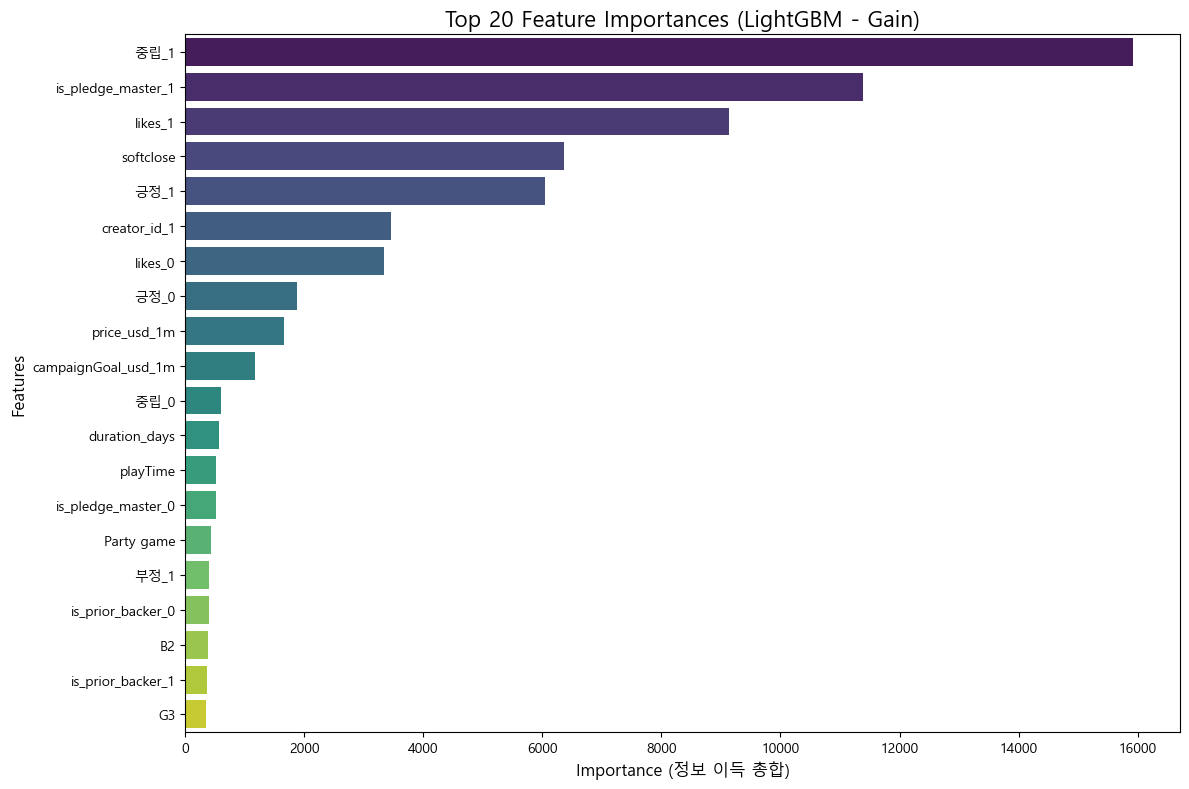


[상위 20개 중요 변수 순위]
 1. 중립_1                           : 15,917.49
 2. is_pledge_master_1             : 11,378.43
 3. likes_1                        : 9,127.38
 4. softclose                      : 6,354.54
 5. 긍정_1                           : 6,047.64
 6. creator_id_1                   : 3,448.11
 7. likes_0                        : 3,340.85
 8. 긍정_0                           : 1,880.56
 9. price_usd_1m                   : 1,656.29
10. campaignGoal_usd_1m            : 1,172.42
11. 중립_0                           : 602.40
12. duration_days                  : 559.10
13. playTime                       : 521.59
14. is_pledge_master_0             : 520.72
15. Party game                     : 434.07
16. 부정_1                           : 403.04
17. is_prior_backer_0              : 392.70
18. B2                             : 376.39
19. is_prior_backer_1              : 370.19
20. G3                             : 345.65


In [20]:
import numpy as np
import pandas as pd
import warnings
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

# 경고 제어 및 시각화 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# ======================================================================
# 1. 학습 피처 및 타깃 변수 설정 (최종 확정 모델: Vis_Low + Txt_3C)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
vis_low = image_features + color_visual

comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
txt_3c = comment_3c

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 중복 제거 및 최종 X 데이터 구성
best_features = list(dict.fromkeys(base_features + vis_low + txt_3c + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

# ======================================================================
# 2. 최종 챔피언 파라미터 적용 및 교차 검증 학습
# ======================================================================
# 이전에 Optuna 100회 탐색으로 찾아낸 최적 파라미터 고정
best_params = {
    'n_estimators': 350, 
    'learning_rate': 0.013706873744930095, 
    'max_depth': 8, 
    'num_leaves': 95, 
    'subsample': 0.720671493562323, 
    'colsample_bytree': 0.4499619435182475, 
    'reg_alpha': 0.009288127226335525, 
    'reg_lambda': 0.0027438295800320633
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 각 Fold별 중요도를 누적할 배열 초기화
feature_importances = np.zeros(X_best.shape[1])

print("[최종 LightGBM 모델 학습 및 중요도 추출 시작]")

for train_idx, test_idx in kf.split(X_best):
    X_tr = X_best.iloc[train_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    final_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
    final_model.fit(X_tr, y_tr_log)
    
    # 모델의 기여도(Gain)를 추출하여 5번 반복 평균을 냅니다.
    # 'gain': 트리의 분기에서 해당 변수가 기여한 오차 감소량(정보 이득)의 총합
    feature_importances += final_model.booster_.feature_importance(importance_type='gain') / kf.n_splits

# ======================================================================
# 3. 중요도 데이터프레임 구성 및 시각화
# ======================================================================
df_importance = pd.DataFrame({
    'Feature': X_best.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 시각화를 위해 상위 20개 변수만 추출
top_n = 20
df_top = df_importance.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_top, palette='viridis')
plt.title(f'Top {top_n} Feature Importances (LightGBM - Gain)', fontsize=16)
plt.xlabel('Importance (정보 이득 총합)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 변수 중요도 결과 출력
print("\n[상위 20개 중요 변수 순위]")
print("=" * 50)
for idx, row in df_top.iterrows():
    print(f"{idx + 1:2d}. {row['Feature']:30s} : {row['Importance']:,.2f}")
print("=" * 50)

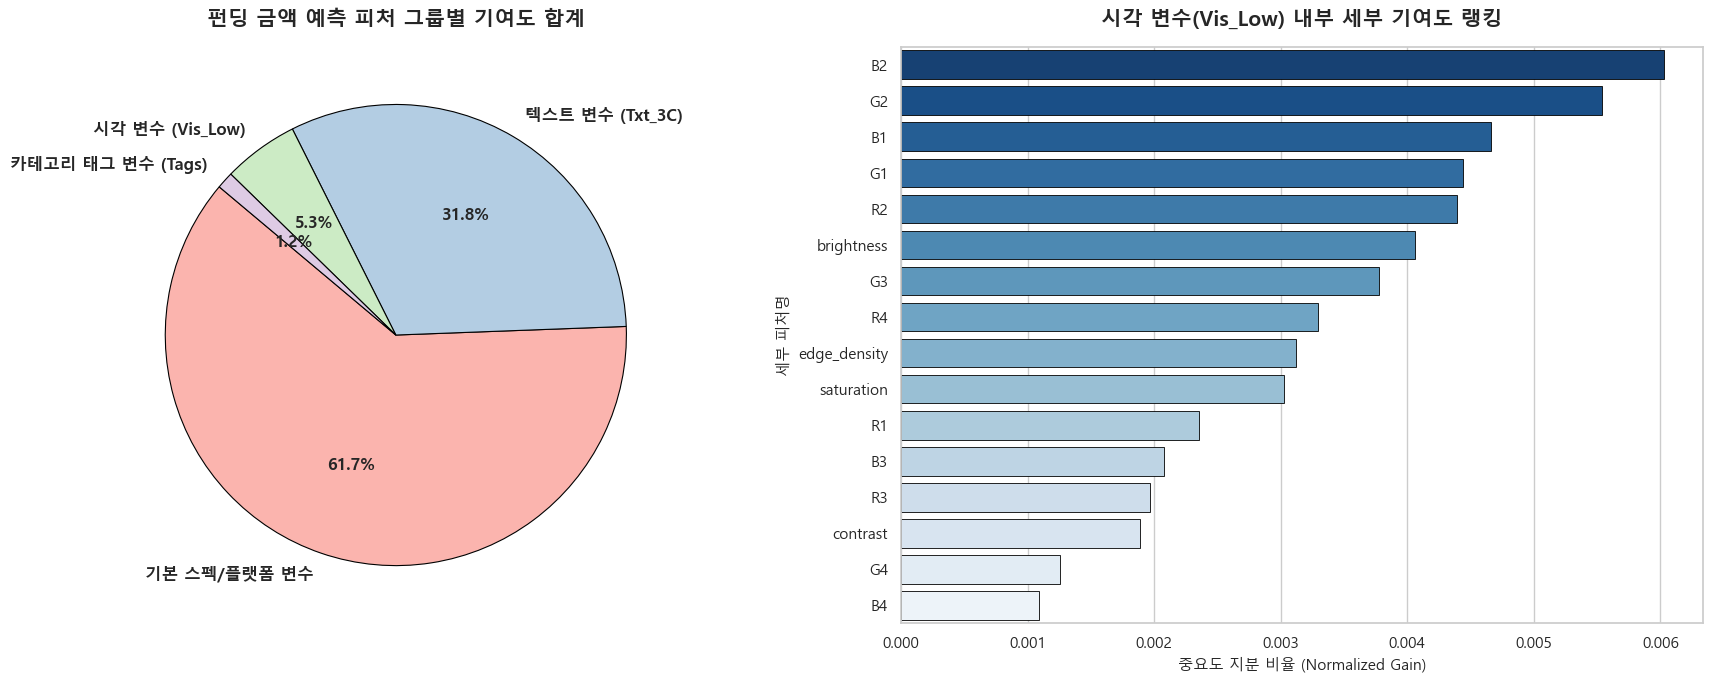


[피처 그룹별 누적 기여도 수치]
--------------------------------------------------
 1위 | 기본 스펙/플랫폼 변수           : 61.71%
 2위 | 텍스트 변수 (Txt_3C)        : 31.81%
 3위 | 시각 변수 (Vis_Low)        : 5.30%
 4위 | 카테고리 태그 변수 (Tags)      : 1.19%
--------------------------------------------------

[시각 변수(Vis_Low) 내부 세부 기여도 순위]
--------------------------------------------------
  1위 | B2                     : 0.60%
  2위 | G2                     : 0.55%
  3위 | B1                     : 0.47%
  4위 | G1                     : 0.44%
  5위 | R2                     : 0.44%
  6위 | brightness             : 0.41%
  7위 | G3                     : 0.38%
  8위 | R4                     : 0.33%
  9위 | edge_density           : 0.31%
 10위 | saturation             : 0.30%
 11위 | R1                     : 0.24%
 12위 | B3                     : 0.21%
 13위 | R3                     : 0.20%
 14위 | contrast               : 0.19%
 15위 | G4                     : 0.13%
 16위 | B4                     : 0.11%
--------------------------------------

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings

# 경고 제어 및 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
warnings.filterwarnings('ignore', category=UserWarning)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# ======================================================================
# 1. 피처 그룹 세팅 및 데이터 준비 (Vis_Low + Txt_3C 적용)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info

# 시각 정보 그룹 (Vis_Low)
image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
vis_low_group = image_features + color_visual

# 텍스트 정보 그룹 (Txt_3C)
txt_3c_group = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 최종 피처 조합
best_features = list(dict.fromkeys(base_features + vis_low_group + txt_3c_group + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

# ======================================================================
# 2. 최종 LightGBM 모델 학습 및 중요도 추출
# ======================================================================
# Optuna 100회 탐색으로 도출된 최종 파라미터 적용
best_params = {
    'n_estimators': 350, 
    'learning_rate': 0.013706873744930095, 
    'max_depth': 8, 
    'num_leaves': 95, 
    'subsample': 0.720671493562323, 
    'colsample_bytree': 0.4499619435182475, 
    'reg_alpha': 0.009288127226335525, 
    'reg_lambda': 0.0027438295800320633
}

champion_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
champion_model.fit(X_best, y_log)

# LightGBM의 Gain 기반 중요도 추출 및 비율(%)로 정규화
raw_importances = champion_model.booster_.feature_importance(importance_type='gain')
normalized_importances = raw_importances / raw_importances.sum()

df_importance = pd.DataFrame({
    'Feature': X_best.columns,
    'Importance': normalized_importances
})

# ======================================================================
# 3. 피처 그룹 매핑
# ======================================================================
def assign_group(feature_name):
    if feature_name in vis_low_group:
        return '시각 변수 (Vis_Low)'
    elif feature_name in txt_3c_group:
        return '텍스트 변수 (Txt_3C)'
    elif feature_name in base_features:
        return '기본 스펙/플랫폼 변수'
    else:
        return '카테고리 태그 변수 (Tags)'

df_importance['Group'] = df_importance['Feature'].apply(assign_group)

# 그룹별 중요도 합계 계산
df_group = df_importance.groupby('Group')['Importance'].sum().reset_index()
df_group = df_group.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ======================================================================
# 4. 종합 시각화 (Pie Chart & Bar Chart)
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 좌측: 그룹별 총합 지분 (Pie Chart)
axes[0].pie(
    df_group['Importance'], 
    labels=df_group['Group'], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=sns.color_palette("Pastel1"),
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[0].set_title('펀딩 금액 예측 피처 그룹별 기여도 합계', fontsize=15, fontweight='bold', pad=15)

# 우측: 시각 변수(Vis_Low) 내 개별 순위 (Bar Chart)
df_vis = df_importance[df_importance['Group'] == '시각 변수 (Vis_Low)'].sort_values(by='Importance', ascending=False)

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_vis, 
    ax=axes[1],
    palette=sns.color_palette("Blues_r", n_colors=len(df_vis)),
    edgecolor='black',
    linewidth=0.6
)
axes[1].set_title('시각 변수(Vis_Low) 내부 세부 기여도 랭킹', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('중요도 지분 비율 (Normalized Gain)', fontsize=11)
axes[1].set_ylabel('세부 피처명', fontsize=11)
axes[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

# ======================================================================
# 5. 분석 결과 텍스트 요약 출력
# ======================================================================
print("\n[피처 그룹별 누적 기여도 수치]")
print("-" * 50)
for idx, row in df_group.iterrows():
    print(f" {idx+1}위 | {row['Group']:<22} : {row['Importance']*100:.2f}%")
print("-" * 50)

print("\n[시각 변수(Vis_Low) 내부 세부 기여도 순위]")
print("-" * 50)
for idx, row in df_vis.reset_index(drop=True).iterrows():
    print(f" {idx+1:>2d}위 | {row['Feature']:<22} : {row['Importance']*100:.2f}%")
print("-" * 50)